<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_5_Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Part 5
## Multiclass Evaluation: Fetal Health Diagnosis

Author: Brad Sheese

---

## Introduction: Beyond Binary

Up to this point, we have focused on binary outcomes: will a customer default or not? But many critical real-world problems involve three or more distinct categories. In medicine, for example, we often need to distinguish between **Normal**, **Suspect**, and **Pathological** states.

In this notebook, we use the **Fetal Health dataset**, which contains metrics derived from cardiotocogram (CTG) exams. Our goal is to classify the health of a fetus into one of three classes. This introduces new complexities in how we evaluate our models; specifically, how we interpret a larger confusion matrix and how we handle severe class imbalance.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Interpret a 3x3 multiclass confusion matrix and identify specific types of misclassification.
2. Explain why accuracy is a dangerous metric for imbalanced multiclass data.
3. Understand the difference between **Macro**, **Weighted**, and **Micro** averaging strategies in a classification report.

## Section 1: The Fetal Health Dataset

The dataset classifies fetal health into three categories based on ultrasound and heart rate metrics:
1. **Normal**
2. **Suspect**
3. **Pathological**

**Note on the Data:** To protect patient privacy and standardize the dataset, the 35 ultrasound metrics have been anonymized into columns `V1` through `V35` (representing metrics like baseline fetal heart rate, uterine contractions, etc.).

Let's load the data and examine the most important characteristic of multiclass problems: the **Class Distribution**.

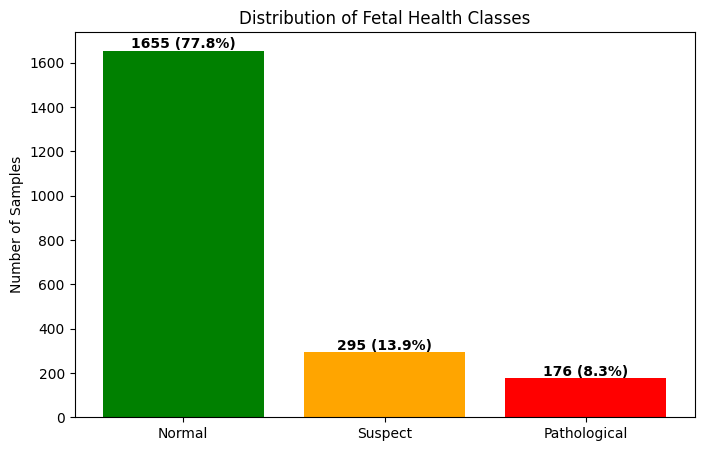

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Load the Cardiotocography dataset (Multiclass version of Fetal Health)
# Class labels: 1 = Normal, 2 = Suspect, 3 = Pathological
data = fetch_openml(data_id=1560, as_frame=True, parser="auto")
df = data.frame

X = df.drop(columns=["Class"])
y = df["Class"].astype(int) - 1 # Shift to 0, 1, 2 for XGBoost
target_names = ["Normal", "Suspect", "Pathological"]

# Examine class distribution
counts = np.bincount(y)
plt.figure(figsize=(8, 5))
plt.bar(target_names, counts, color=["green", "orange", "red"])
plt.title("Distribution of Fetal Health Classes")
plt.ylabel("Number of Samples")
for i, count in enumerate(counts):
    plt.text(i, count + 10, f"{count} ({count/len(y):.1%})", ha="center", fontweight="bold")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### The Imbalance Trap

Notice that **77.8%** of the samples are 'Normal'. This is a classic "imbalanced" dataset.

If a model simply predicted "Normal" for every single patient, it would achieve nearly **78% accuracy** while failing to catch 100% of the life-threatening 'Pathological' cases. In multiclass classification, accuracy is often the least useful metric we have. We must dig deeper into the errors.

## Section 2: The 3x3 Confusion Matrix

When we have 3 classes, our confusion matrix becomes a 3x3 grid. Let's train an XGBoost model and look at where it's making mistakes.

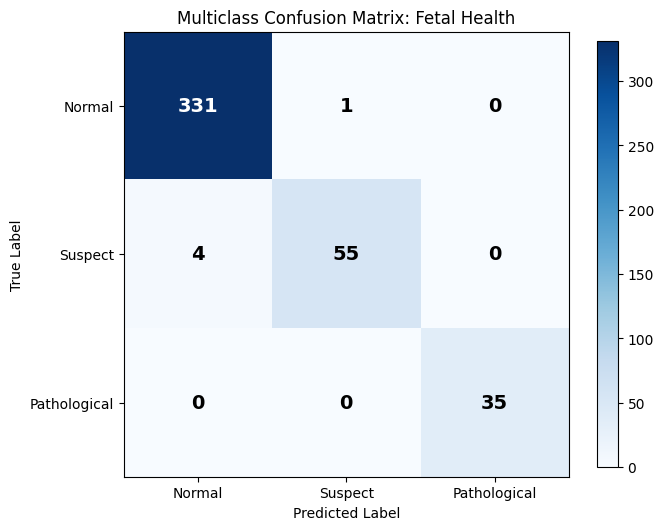

In [ ]:
# Train a multiclass XGBoost model
model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(target_names)
ax.set_yticklabels(target_names)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Multiclass Confusion Matrix: Fetal Health")

for i in range(3):
    for j in range(3):
        label = f"{cm[i, j]}"
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, label, ha="center", va="center", fontsize=14, fontweight="bold", color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### Identifying Critical Errors

The diagonal represents correct predictions. The off-diagonal cells represent misclassifications. In a clinical setting, not all errors are equal:

1. **False Alarm:** Predicting 'Suspect' or 'Pathological' when the fetus is 'Normal'. This leads to unnecessary stress and testing.
2. **Fatal Miss:** Predicting 'Normal' when the fetus is actually 'Pathological'. This is the most dangerous error because a critical condition goes untreated.

**Look at the 'Pathological' row (bottom row):** How many pathological cases did the model miss by predicting 'Normal' or 'Suspect' instead?

**Did you spot the misses?** Depending on the exact train/test split, the model likely predicted 'Normal' or 'Suspect' for a few cases that were actually 'Pathological'. Even if the overall accuracy is high, in a clinical setting, missing even 3 or 4 pathological cases is unacceptable. This is why we must look at the specific off-diagonal numbers, not just the global score.

## Section 3: The Averaging Problem (Macro vs. Weighted)

How do we turn a 3x3 matrix into a single score like Precision or F1? We have to "average" the results across classes. But there are three different ways to do it, and they tell very different stories.

In [ ]:
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Full Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       332
     Suspect       0.98      0.93      0.96        59
Pathological       1.00      1.00      1.00        35

    accuracy                           0.99       426
   macro avg       0.99      0.98      0.98       426
weighted avg       0.99      0.99      0.99       426



### Which Average Should You Use?

1.  **Macro Avg:** This treats all classes as equally important. It calculates the F1-score for Normal, Suspect, and Pathological separately, then takes the simple arithmetic mean.
    *   *Why use it?* It is the "fairest" metric for imbalanced data. If your model is terrible at the rare 'Pathological' class, the Macro Avg will be low, even if your 'Normal' score is perfect.

2.  **Weighted Avg:** This weights each class's score by its "support" (the number of samples in that class).
    *   *Why use it?* It reflects the overall performance of the model on the population. However, it can be deceptive: if you are great at the majority class ('Normal') but fail the rare class, the Weighted Avg will still look high because 'Normal' dominates the calculation.

3.  **Accuracy (equivalent to Micro Avg):** This is calculated globally by counting the total true positives, false negatives, and false positives.
    *   *Note:* Scikit-Learn's report simply labels this as `accuracy` because, in standard multiclass problems, Micro Precision, Micro Recall, and Micro F1 all evaluate to the exact same number: overall accuracy.

**Rule of Thumb:** In imbalanced multiclass problems, **Macro F1** is usually your best indicator of how well the model is actually performing across the board.

## Conclusion

We have moved from binary classification to the more complex world of multiclass. Key takeaways:

1. **Imbalance is the Norm:** In multiclass problems, classes are rarely balanced. Always check your class distribution first.
2. **Confusion Matrices Scale:** A 3x3 (or NxN) matrix allows you to see specifically which labels are being swapped (e.g., confusing 'Pathological' for 'Suspect').
3. **Macro over Weighted:** When classes are imbalanced, trust the **Macro Average** to tell you the truth about your model's performance on minority categories.
